# Phase 1B: extreme-case construct diagnostics

Metrica Sample Game 1 only. Two short open-play positive-control candidates were manually selected from raw tracking frames before inspecting diagnostic coordinates. They are not tactical labels or inferred assignments. This notebook retains only the existing leave-one-out outfield-team centroid and defender–attacker coordinates, with no smoothing, derivatives, thresholds, classification, states, scores, or additional structural references. Coordinates remain raw and nominally normalized.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
DATA = ROOT / 'data' / 'metrica_sample_game_1'
HOME_PATH = DATA / 'Sample_Game_1_RawTrackingData_Home_Team.csv'
AWAY_PATH = DATA / 'Sample_Game_1_RawTrackingData_Away_Team.csv'
EVENT_PATH = DATA / 'Sample_Game_1_RawEventsData.csv'
def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''): h.update(block)
    return h.hexdigest()
pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)], 'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path, team):
    header = pd.read_csv(path, header=None, nrows=3)
    players = [str(int(float(v))) for v in header.iloc[1,3:-2:2] if pd.notna(v)]
    columns = ['Period','Frame','Time [s]']
    for player in players: columns += [f'{team}_{player}_x',f'{team}_{player}_y']
    columns += ['ball_x','ball_y']
    return pd.read_csv(path,skiprows=3,names=columns)
home = load_tracking(HOME_PATH,'Home'); away = load_tracking(AWAY_PATH,'Away'); events = pd.read_csv(EVENT_PATH)
home.shape, away.shape, events.shape

((145006, 33), (145006, 33), (1745, 14))

## Selection record — frozen before diagnostic inspection

Selections were made by stepping through raw full-team frames and looking for unusually legible soccer movements, not favorable metric behavior.

- **Track candidate:** period 1, 1888–1896 s; Home Player4 and Away Player18. They move substantially while appearing to preserve a recognizable opponent-relative relationship.
- **Close candidate:** period 2, 4388–4392.5 s; Home Player6 and Away Player19. Player6 appears to reduce the separation actively as play develops.

The choices are fixed. The plots below reproduce the raw views used for selection; no relative-coordinate or distance diagnostic has yet been calculated.

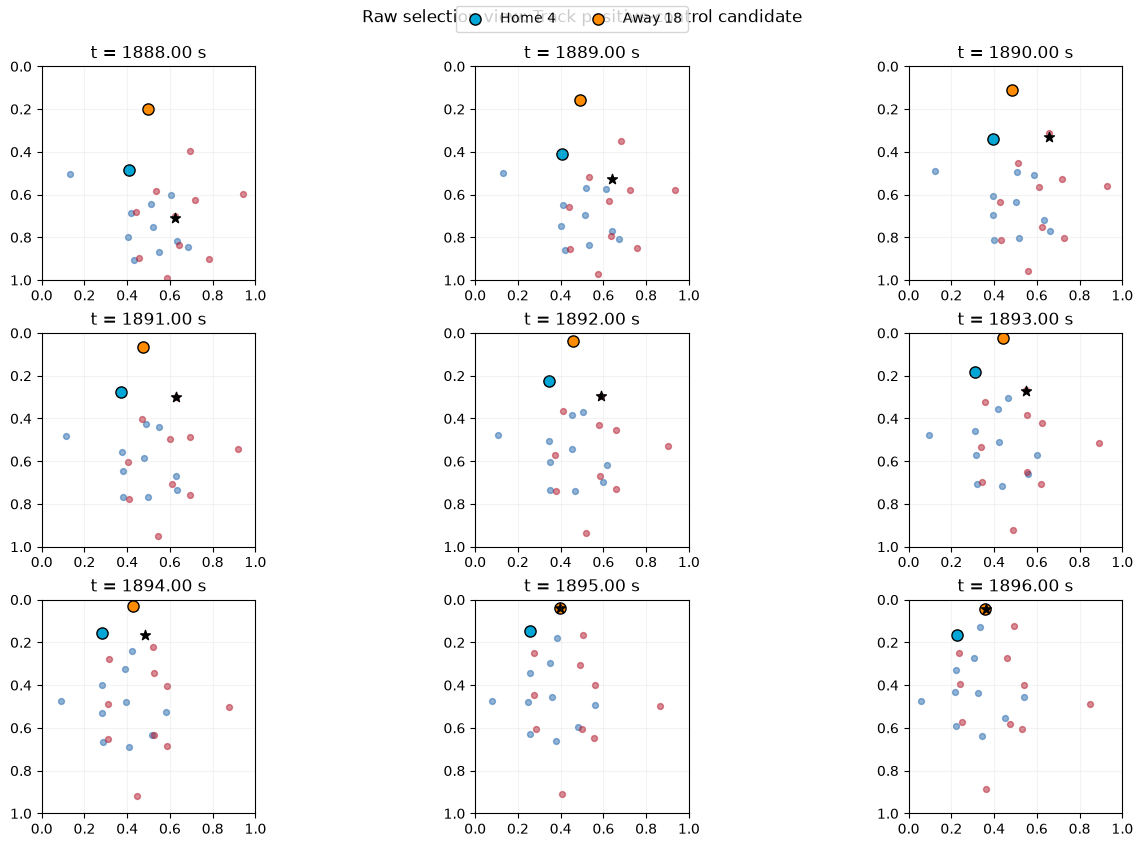

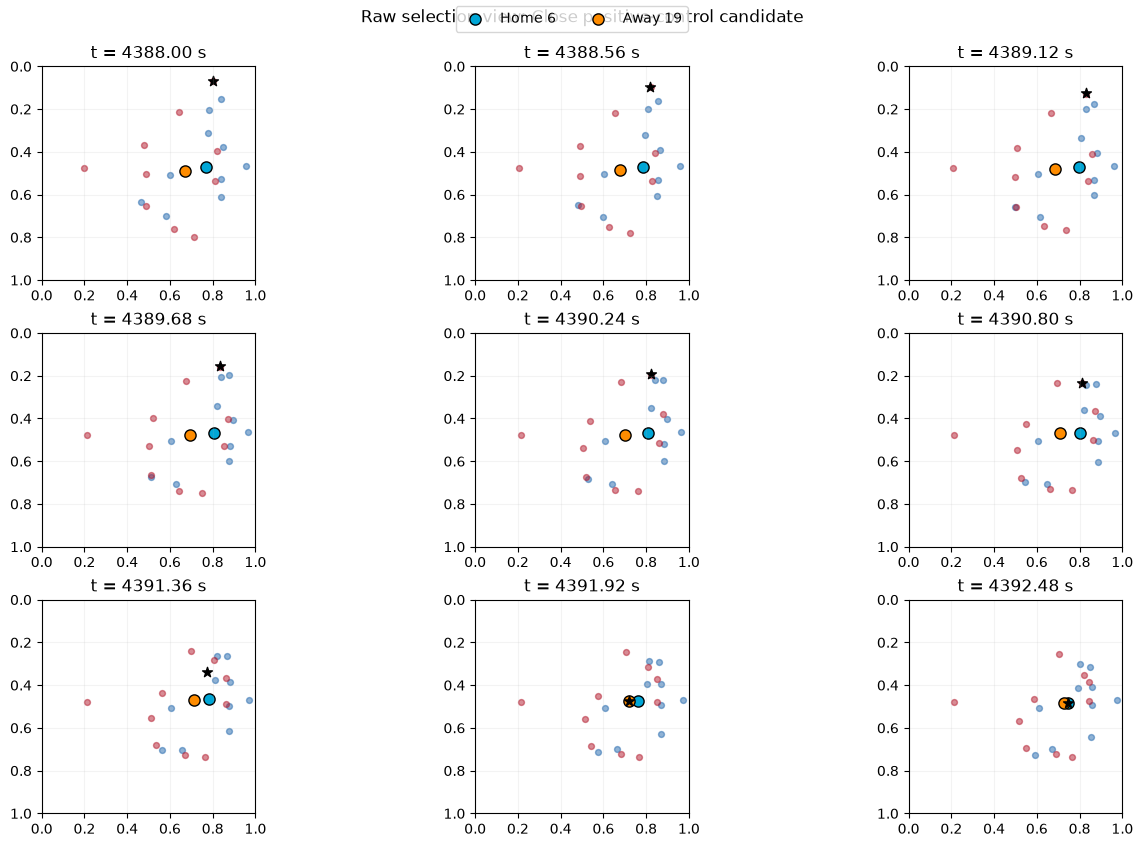

In [3]:
TRACK={'period':1,'start':1888.0,'end':1896.0,'defender':'4','attacker':'18'}
CLOSE={'period':2,'start':4388.0,'end':4392.5,'defender':'6','attacker':'19'}
def window(df,s): return df[(df['Period']==s['period']) & df['Time [s]'].between(s['start'],s['end'])].copy()
def player_ids(df,team): return sorted({c.split('_')[1] for c in df if c.startswith(team+'_') and c.endswith('_x')},key=int)
def raw_contact_sheet(spec,title):
    hw,aw=window(home,spec),window(away,spec); idx=np.linspace(0,len(hw)-1,9,dtype=int)
    fig,axes=plt.subplots(3,3,figsize=(13,8),constrained_layout=True)
    for ax,i in zip(axes.flat,idx):
        hr,ar=hw.iloc[i],aw.iloc[i]
        for p in player_ids(home,'Home'): ax.scatter(hr[f'Home_{p}_x'],hr[f'Home_{p}_y'],c='#2166ac',s=18,alpha=.5)
        for p in player_ids(away,'Away'): ax.scatter(ar[f'Away_{p}_x'],ar[f'Away_{p}_y'],c='#b2182b',s=18,alpha=.5)
        ax.scatter(hr[f"Home_{spec['defender']}_x"],hr[f"Home_{spec['defender']}_y"],c='#00a6d6',s=65,edgecolor='black',label=f"Home {spec['defender']}")
        ax.scatter(ar[f"Away_{spec['attacker']}_x"],ar[f"Away_{spec['attacker']}_y"],c='#ff8c00',s=65,edgecolor='black',label=f"Away {spec['attacker']}")
        ax.scatter(hr.ball_x,hr.ball_y,c='black',marker='*',s=55)
        ax.set(xlim=(0,1),ylim=(1,0),aspect='equal',title=f"t = {hr['Time [s]']:.2f} s"); ax.grid(alpha=.15)
    fig.legend(*axes.flat[0].get_legend_handles_labels(),loc='upper center',ncol=2); fig.suptitle(title,y=1.04); plt.show()
raw_contact_sheet(TRACK,'Raw selection view: Track positive-control candidate')
raw_contact_sheet(CLOSE,'Raw selection view: Close positive-control candidate')

Event records below provide context after visual selection; they are not tactical labels.

In [4]:
cols=['Team','Type','Subtype','Period','Start Frame','Start Time [s]','End Time [s]','From','To']
events[((events.Period==1)&events['Start Time [s]'].between(1885,1897))|((events.Period==2)&events['Start Time [s]'].between(4387,4394))][cols]

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Time [s],From,To
579,Away,SET PIECE,THROW IN,1,47146,1885.84,1885.84,Player22,NaN
580,Away,PASS,NaN,1,47146,1885.84,1888.16,Player22,Player21
581,Away,PASS,NaN,1,47204,1888.16,1890.08,Player21,Player15
582,Away,PASS,NaN,1,47337,1893.48,1894.80,Player15,Player18
1344,Away,PASS,NaN,2,109775,4391.00,4391.88,Player27,Player19
1345,Home,CHALLENGE,TACKLE-WON,2,109812,4392.48,4392.48,Player6,NaN
1346,Home,RECOVERY,THEFT,2,109812,4392.48,4392.48,Player6,NaN
1347,Away,CHALLENGE,TACKLE-LOST,2,109813,4392.52,4392.52,Player19,NaN
1348,Away,BALL LOST,THEFT,2,109813,4392.52,4392.72,Player19,NaN
1349,Home,PASS,NaN,2,109815,4392.60,4394.00,Player6,Player10


## Track candidate diagnostic

The existing reference is the framewise arithmetic mean of the other active Home outfield players' raw x/y coordinates. Home Player4 and goalkeeper Player11 are excluded. No interpolation or smoothing is applied. Away Player18 is illustrative and manually selected, not an inferred responsibility.

Centroid contributors: ['2', '3', '5', '6', '7', '8', '9', '10', '12']


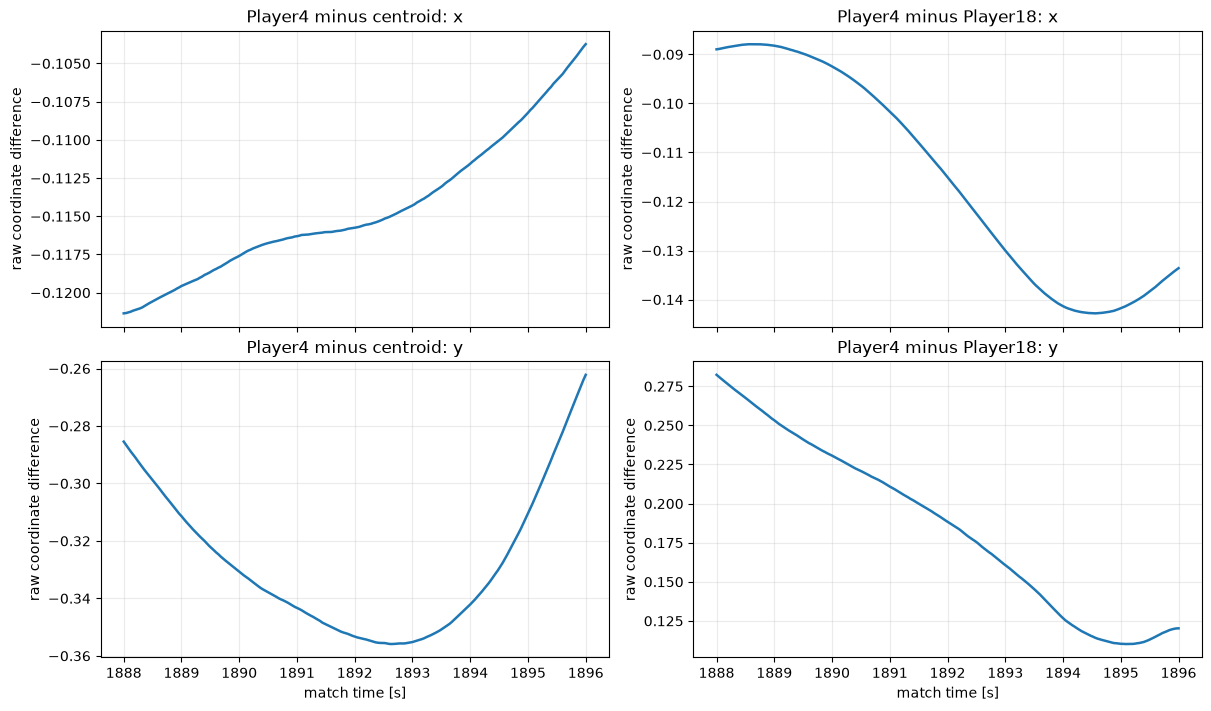

,representation,component,span,start,end
0,team centroid,x,0.017623,-0.121356,-0.103732
1,attacker,x,0.054910,-0.088960,-0.133590
2,team centroid,y,0.093702,-0.285434,-0.262186
3,attacker,y,0.172130,0.282340,0.120240


In [5]:
th,ta=window(home,TRACK),window(away,TRACK)
track=th.merge(ta[['Frame','Away_18_x','Away_18_y']],on='Frame',validate='one_to_one')
refs=[p for p in player_ids(home,'Home') if p not in {'4','11'} and track[f'Home_{p}_x'].notna().any()]
track['centroid_x']=track[[f'Home_{p}_x' for p in refs]].mean(axis=1); track['centroid_y']=track[[f'Home_{p}_y' for p in refs]].mean(axis=1)
for axis in ['x','y']:
    track[f'centroid_relative_{axis}']=track[f'Home_4_{axis}']-track[f'centroid_{axis}']
    track[f'attacker_relative_{axis}']=track[f'Home_4_{axis}']-track[f'Away_18_{axis}']
print('Centroid contributors:',refs)
fig,axes=plt.subplots(2,2,figsize=(12,7),sharex=True,constrained_layout=True)
series=[('centroid_relative_x','Player4 minus centroid: x'),('attacker_relative_x','Player4 minus Player18: x'),('centroid_relative_y','Player4 minus centroid: y'),('attacker_relative_y','Player4 minus Player18: y')]
for ax,(c,title) in zip(axes.flat,series): ax.plot(track['Time [s]'],track[c],lw=1.8); ax.set(title=title,ylabel='raw coordinate difference'); ax.grid(alpha=.25)
for ax in axes[-1]: ax.set_xlabel('match time [s]')
plt.show()
pd.DataFrame({'representation':['team centroid','attacker']*2,'component':['x','x','y','y'],'span':[track[c].max()-track[c].min() for c,_ in series],'start':[track[c].iloc[0] for c,_ in series],'end':[track[c].iloc[-1] for c,_ in series]})

### Track-candidate observations

The raw frames motivated this candidate because Player4 and Player18 move substantially in broadly similar directions. The diagnostic does **not** make attacker-relative coordinates distinctly more stable: their x and y spans are larger than the corresponding centroid-relative spans. Visual co-movement therefore coexists with a changing relative vector, challenging a simple Structure/Track expectation.

Alternatives include coordinated team translation, line maintenance, zonal coverage, ball or passing-lane response, temporary closing, and coincidental co-movement. This establishes neither a Track state nor Player18 as Player4's responsibility.

## Close candidate diagnostic

The raw trajectory remains primary. Defender–attacker x/y differences remain alongside Euclidean distance. Distance is in raw normalized-coordinate units; because x and y correspond to different physical pitch dimensions, it is not metric distance in metres. No coordinate normalization is added.

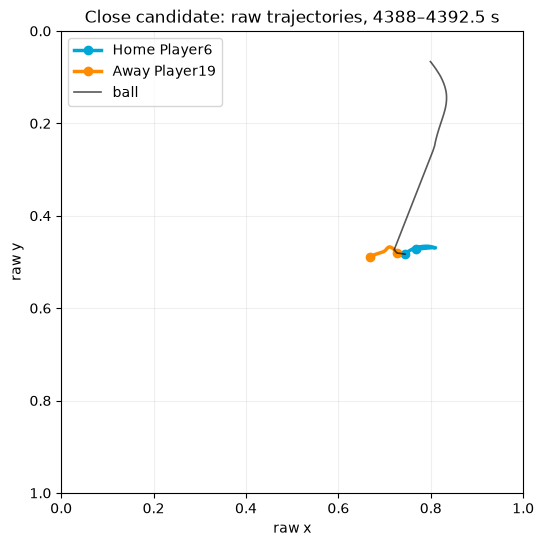

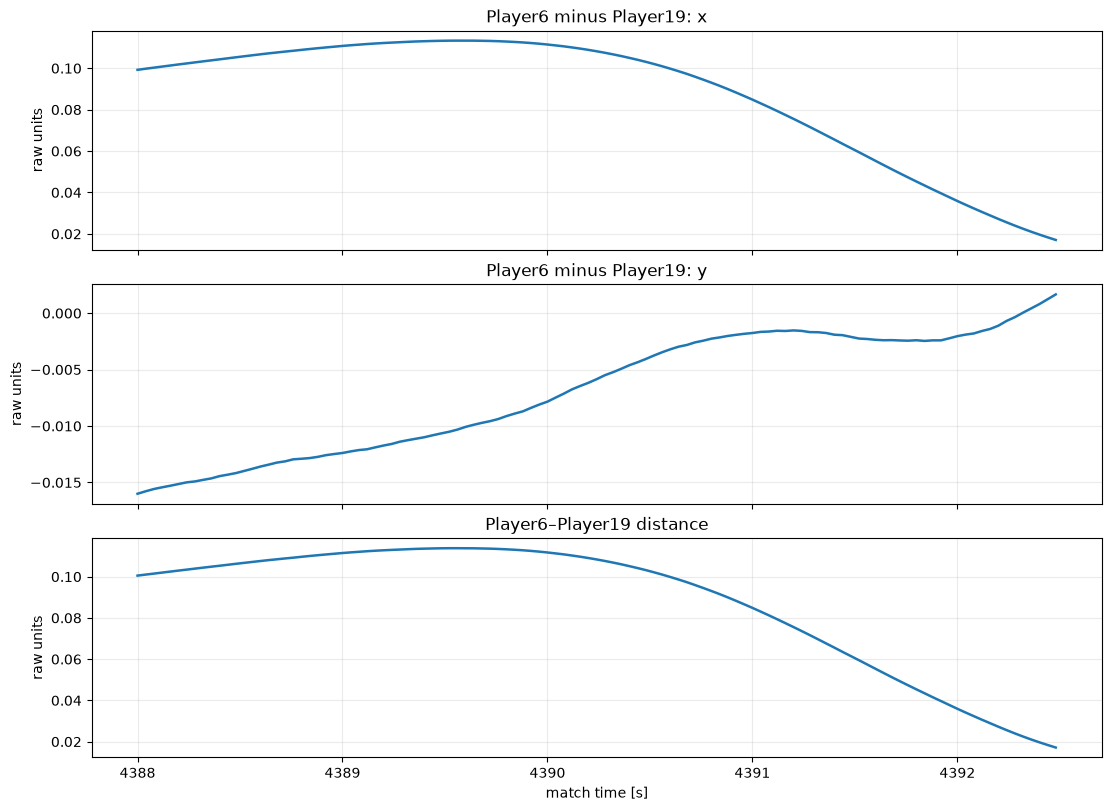

,quantity,start,end,minimum,maximum,span
0,defender_minus_attacker_x,0.099230,0.017060,0.017060,0.113330,0.096270
1,defender_minus_attacker_y,-0.016000,0.001660,-0.016000,0.001660,0.017660
2,distance_raw_units,0.100512,0.017141,0.017141,0.113799,0.096658


In [6]:
ch,ca=window(home,CLOSE),window(away,CLOSE)
close=ch.merge(ca[['Frame','Away_19_x','Away_19_y']],on='Frame',validate='one_to_one')
close['defender_minus_attacker_x']=close.Home_6_x-close.Away_19_x; close['defender_minus_attacker_y']=close.Home_6_y-close.Away_19_y
close['distance_raw_units']=np.sqrt(close.defender_minus_attacker_x**2+close.defender_minus_attacker_y**2)
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(close.Home_6_x,close.Home_6_y,color='#00a6d6',lw=2.5,marker='o',markevery=[0,-1],label='Home Player6')
ax.plot(close.Away_19_x,close.Away_19_y,color='#ff8c00',lw=2.5,marker='o',markevery=[0,-1],label='Away Player19')
ax.plot(close.ball_x,close.ball_y,color='black',lw=1.2,alpha=.65,label='ball')
ax.set(xlim=(0,1),ylim=(1,0),aspect='equal',xlabel='raw x',ylabel='raw y',title='Close candidate: raw trajectories, 4388–4392.5 s'); ax.grid(alpha=.2); ax.legend(); plt.show()
fig,axes=plt.subplots(3,1,figsize=(11,8),sharex=True,constrained_layout=True)
quantities=[('defender_minus_attacker_x','Player6 minus Player19: x'),('defender_minus_attacker_y','Player6 minus Player19: y'),('distance_raw_units','Player6–Player19 distance')]
for ax,(c,title) in zip(axes,quantities): ax.plot(close['Time [s]'],close[c],lw=1.8); ax.set(title=title,ylabel='raw units'); ax.grid(alpha=.25)
axes[-1].set_xlabel('match time [s]'); plt.show()
pd.DataFrame([{'quantity':c,'start':close[c].iloc[0],'end':close[c].iloc[-1],'minimum':close[c].min(),'maximum':close[c].max(),'span':close[c].max()-close[c].min()} for c,_ in quantities])

### Close-candidate observations

Raw-coordinate separation declines markedly by the window end, almost entirely through x; y remains comparatively small. The event file records an Away pass to Player19 followed by a Home Player6 tackle won near the end. That is consistent with visible convergence but does not determine tactical meaning.

Alternatives include Player19 moving toward Player6, ball or passing-lane response, maintaining or stepping from the line, team compression, an immediate tackle action rather than a sustained closing construct, and coincidental convergence. This shows geometric closure only—not intent, assignment, a Close state, or a decision rule.

**Stopping point:** no further examples or methods are introduced.